In [1]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

player_statistics = pd.read_csv("/Users/student/Downloads/Math 2320 Final Project/nba_cleaned.csv")

In [2]:
player_statistics['fullName'] = player_statistics['firstName'] + ' ' +  player_statistics['lastName']
player_stats_modern = player_statistics[player_statistics['year'] >= 2003]
player_stats_prepped = player_stats_modern.select_dtypes(include='number').drop(columns = ['personId', 'year', 'decade', 'games_played', 'total_minutes'])
features = player_stats_prepped.columns
player_stats_prepped = np.array(player_stats_prepped)

scaler_modern = StandardScaler()
scaled_stats = scaler_modern.fit_transform(player_stats_prepped)

pca_modern = PCA(n_components = 3)

In [3]:
players_reduced_modern = pca_modern.fit_transform(scaled_stats)

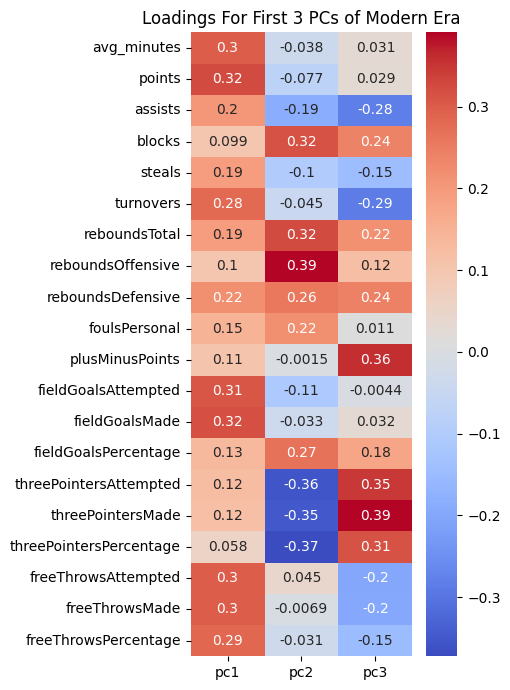

In [4]:
def create_3_pc_heatmap(pca, time_period):
  loadings = pd.DataFrame(pca.components_.T, index=features, columns = ['pc1', 'pc2', 'pc3'])
  fig, ax = plt.subplots(figsize=(5,7))
  sns.heatmap(loadings, annot=True, cmap='coolwarm')
  ax.set_title(f"Loadings For First 3 PCs of {time_period}")
  fig.tight_layout()

create_3_pc_heatmap(pca_modern, "Modern Era")

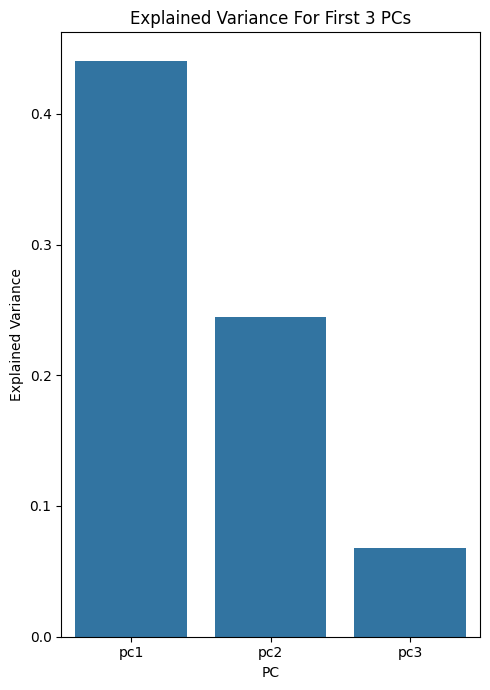

In [5]:
fig, ax = plt.subplots(figsize=(5,7))
explained_variances = pd.DataFrame(pca_modern.explained_variance_ratio_, index=['pc1', 'pc2', 'pc3'], columns = ['Explained Variance'])
sns.barplot(data=explained_variances, x = explained_variances.index, y='Explained Variance')
ax.set_title("Explained Variance For First 3 PCs")
ax.set_xlabel("PC")
fig.tight_layout()

In [6]:
players_pcs_modern = pd.DataFrame(players_reduced_modern, columns = ['pc1', 'pc2', 'pc3'])
players_pcs_modern['year'] = player_stats_modern['year'].reset_index(drop=True)
players_pcs_modern['fullName'] = player_stats_modern['fullName'].reset_index(drop=True)
lebron_pcs = players_pcs_modern[players_pcs_modern['fullName'].str.contains("LeBron")]
lebron_pcs.index = lebron_pcs['year']

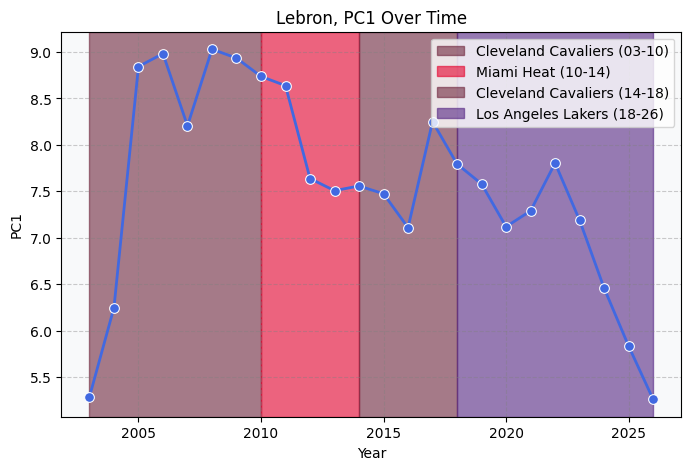

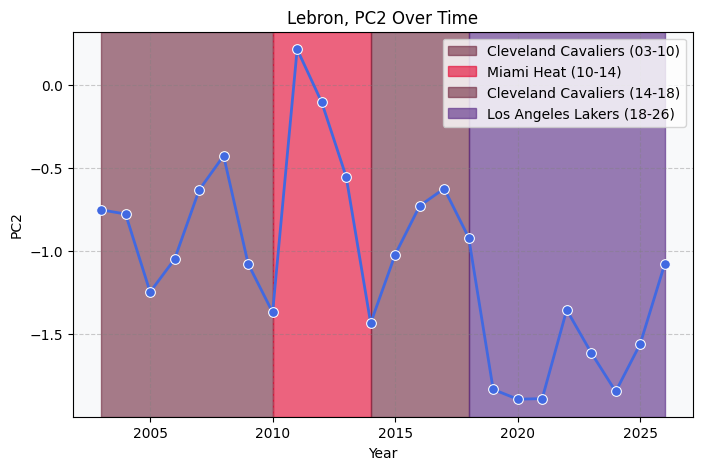

In [7]:
def generate_pc_graph_over_time(data, pc_num, name, eras=None, comp=None, comp_label=None):
  fig, ax = plt.subplots(figsize=(8,5))
  if eras:
    for era in eras:
      ax.axvspan(era['start'], era['end'], alpha=0.6, color=era['color'], label=era['name'])

  sns.lineplot(data=data, x='year', y= 'pc{}'.format(pc_num), marker = 'o', color='royalblue', linewidth=2, markersize=7, ax=ax)

  ax.set_title(f"{name}, PC{pc_num} Over Time")
  ax.set_xlabel("Year")
  ax.set_ylabel("PC{}".format(pc_num))

  ax.set_facecolor('#f8f9fa')
  ax.grid(True, linestyle='--', alpha=0.4, color='gray')
  if eras:
    sns.move_legend(ax, "upper right")

  plt.show()

lebron_teams = teams = [
    {"name": "Cleveland Cavaliers (03-10)", "start": 2003, "end": 2010, "color": "#6F263D"},
    {"name": "Miami Heat (10-14)",          "start": 2010, "end": 2014, "color": "#E4002B"},
    {"name": "Cleveland Cavaliers (14-18)", "start": 2014, "end": 2018, "color": "#6F263D"},
    {"name": "Los Angeles Lakers (18-26)",  "start": 2018, "end": 2026, "color": "#552583"},
]

generate_pc_graph_over_time(lebron_pcs, 1, "Lebron", eras=lebron_teams)
generate_pc_graph_over_time(lebron_pcs, 2, "Lebron", eras=lebron_teams)


In [8]:
# Run PCA on all data
player_stats_all_time = player_statistics[player_statistics['year'] >= 1960]
player_stats_prepped = player_stats_all_time.select_dtypes(include='number').drop(columns = ['personId', 'year', 'decade', 'games_played', 'total_minutes'])
features = player_stats_prepped.columns
player_stats_prepped = np.array(player_stats_prepped)

scaler_all_time = StandardScaler()
scaled_stats = scaler_all_time.fit_transform(player_stats_prepped)

pca_all_time = PCA(n_components = 3)

In [10]:
players_reduced_all_time = pca_all_time.fit_transform(scaled_stats)

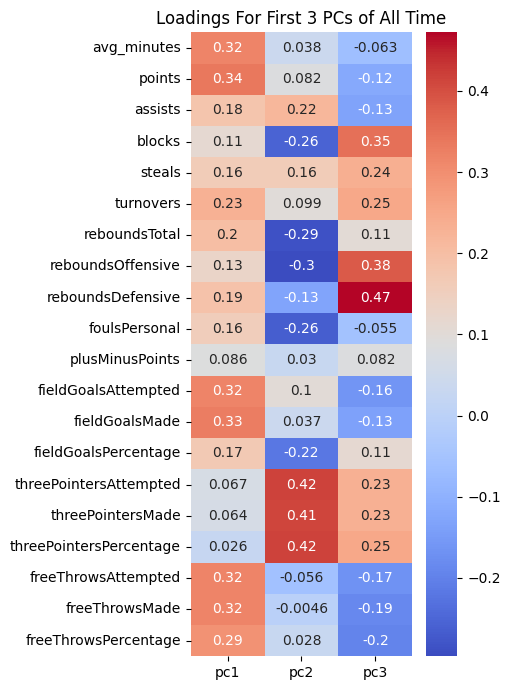

In [11]:
create_3_pc_heatmap(pca_all_time, "All Time")

In [12]:
players_pcs_all_time = pd.DataFrame(players_reduced_all_time, columns = ['pc1', 'pc2', 'pc3'])
players_pcs_all_time['year'] = player_stats_all_time['year'].reset_index(drop=True)

In [13]:
players_pcs_all_time_averages = players_pcs_all_time.groupby('year').agg(['mean',  'std'])

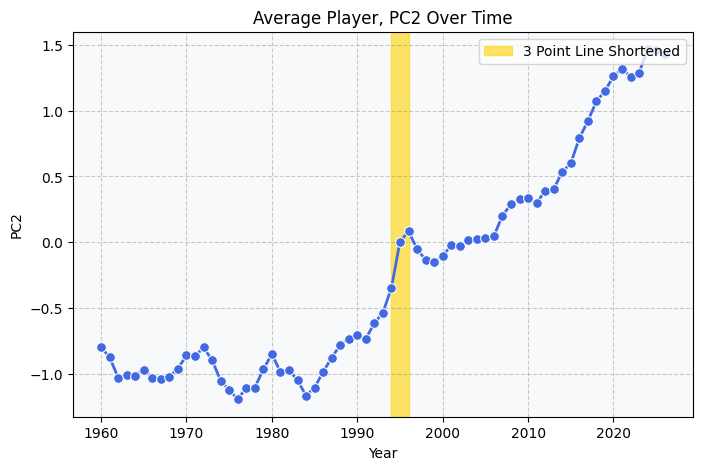

In [14]:
eras = [
    {'name': "3 Point Line Shortened", 'start': 1994, 'end':1996, 'color': '#FFD300'}
]

generate_pc_graph_over_time(players_pcs_all_time_averages.pc2.rename(columns={'mean':'pc2'}), 2, "Average Player", eras=eras)